File version: 1.1

In [1]:
import sys;

print('Python %s on %s' % (sys.version, sys.platform))
sys.path.extend(['../'])
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score

from scripts.data_utils import get_connectome

Python 3.12.3 (tags/v3.12.3:f6650f9, Apr  9 2024, 14:05:25) [MSC v.1938 64 bit (AMD64)] on win32


In [2]:
bnu_series_path = '../data/ts_cut/HCPex/bnu{}.npy'
bnu_labels_path = '../data/ts_cut/HCPex/bnu.csv'
ihb_series_path = '../data/ts_cut/HCPex/ihb.npy'
ihb_labels_path = '../data/ts_cut/HCPex/ihb.csv'

X_bnu = np.concatenate([np.load(bnu_series_path.format(i)) for i in (1, 2)], axis=0)
Y_bnu = pd.read_csv(bnu_labels_path)
X_ihb = np.load(ihb_series_path)
Y_ihb = pd.read_csv(ihb_labels_path)

X_bnu = get_connectome(X_bnu)
X_ihb = get_connectome(X_ihb)

In [3]:
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        layers = []
        layers.append(nn.Linear(input_size, 128))
        layers.append(nn.Linear(128, 64))
        layers.append(nn.Linear(64, 32))
        layers.append(nn.Linear(32, 1))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return torch.sigmoid(self.model(x))


X_bnu_train, X_bnu_val, Y_bnu_train, Y_bnu_val = train_test_split(X_bnu, Y_bnu, test_size=0.035)
X_ihb_train, X_ihb_val, Y_ihb_train, Y_ihb_val = train_test_split(X_ihb, Y_ihb, test_size=0.2)
print(X_bnu_val.shape[0], X_ihb_val.shape[0])

X_train = np.concatenate([X_bnu_train, X_ihb_train])
X_val = np.concatenate([X_bnu_val, X_ihb_val])
X_train = X_train.reshape(X_train.shape[0], -1).astype('float32')
X_val = X_val.reshape(X_val.shape[0], -1).astype('float32')
X_ihb_val = X_ihb_val.reshape(X_ihb_val.shape[0], -1).astype('float32')

Y_train = np.concatenate([Y_bnu_train, Y_ihb_train]).astype('float32')
Y_val = np.concatenate([Y_bnu_val, Y_ihb_val]).astype('float32')
Y_ihb_val = Y_ihb_val.to_numpy().astype('float32')
print(X_train.shape, Y_train.shape)


X_train_tensor = torch.tensor(X_train)
Y_train_tensor = torch.tensor(Y_train).view(-1, 1)
X_val_tensor = torch.tensor(X_val)
Y_val_tensor = torch.tensor(Y_val).view(-1, 1)
X_ihb_val_tensor = torch.tensor(X_ihb_val)
Y_ihb_val_tensor = torch.tensor(Y_ihb_val).view(-1, 1)


model = MLP(X_train_tensor.shape[1])
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=1e-3)


train_losses = []
val_losses = []
accuracies = []
f1_scores = []

best_val = float('inf')
best_epoch = 0
patience = 50
patience_counter = 0
best_model_weights = None

num_epochs = 5000
for epoch in range(num_epochs):
    model.train()

    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, Y_train_tensor)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, Y_val_tensor)
        val_losses.append(val_loss.item())

        ihb_val_outputs = model(X_ihb_val_tensor)
        ihb_val_predictions = (ihb_val_outputs.view(-1) >= 0.5).float()

        accuracy = accuracy_score(Y_ihb_val_tensor, ihb_val_predictions.cpu().numpy())
        f1 = f1_score(Y_ihb_val_tensor, ihb_val_predictions.cpu().numpy())
        accuracies.append(accuracy)
        f1_scores.append(f1)

    if val_loss < best_val:
        best_val = val_loss
        best_model_weights = model.state_dict()
        patience_counter = 0
        best_epoch = epoch + 1
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f'Early stopping at epoch {epoch + 1}')
        break

    print(f'Epoch [{epoch + 1}/{num_epochs}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, Accuracy: {accuracy:.2f}, F1 Score: {f1:.2f}')


model.load_state_dict(best_model_weights)
model.eval()
with torch.no_grad():
    val_outputs = model(X_ihb_val_tensor)
val_predictions = (val_outputs.view(-1) >= 0.5).float()
print(accuracy_score(Y_ihb_val_tensor, val_predictions.cpu().numpy()))
print(f1_score(Y_ihb_val_tensor, val_predictions.cpu().numpy()))

5 4
(153, 175561) (153, 1)
Epoch [1/5000], Train Loss: 0.7188, Val Loss: 0.6818, Accuracy: 0.75, F1 Score: 0.86
Epoch [2/5000], Train Loss: 0.6952, Val Loss: 0.6827, Accuracy: 1.00, F1 Score: 1.00
Epoch [3/5000], Train Loss: 0.6776, Val Loss: 0.6847, Accuracy: 0.25, F1 Score: 0.00
Epoch [4/5000], Train Loss: 0.6641, Val Loss: 0.6869, Accuracy: 0.25, F1 Score: 0.00
Epoch [5/5000], Train Loss: 0.6533, Val Loss: 0.6892, Accuracy: 0.25, F1 Score: 0.00
Epoch [6/5000], Train Loss: 0.6444, Val Loss: 0.6911, Accuracy: 0.25, F1 Score: 0.00
Epoch [7/5000], Train Loss: 0.6367, Val Loss: 0.6926, Accuracy: 0.25, F1 Score: 0.00
Epoch [8/5000], Train Loss: 0.6300, Val Loss: 0.6936, Accuracy: 0.25, F1 Score: 0.00
Epoch [9/5000], Train Loss: 0.6238, Val Loss: 0.6942, Accuracy: 0.25, F1 Score: 0.00
Epoch [10/5000], Train Loss: 0.6181, Val Loss: 0.6943, Accuracy: 0.25, F1 Score: 0.00
Epoch [11/5000], Train Loss: 0.6126, Val Loss: 0.6940, Accuracy: 0.25, F1 Score: 0.00
Epoch [12/5000], Train Loss: 0.6073,

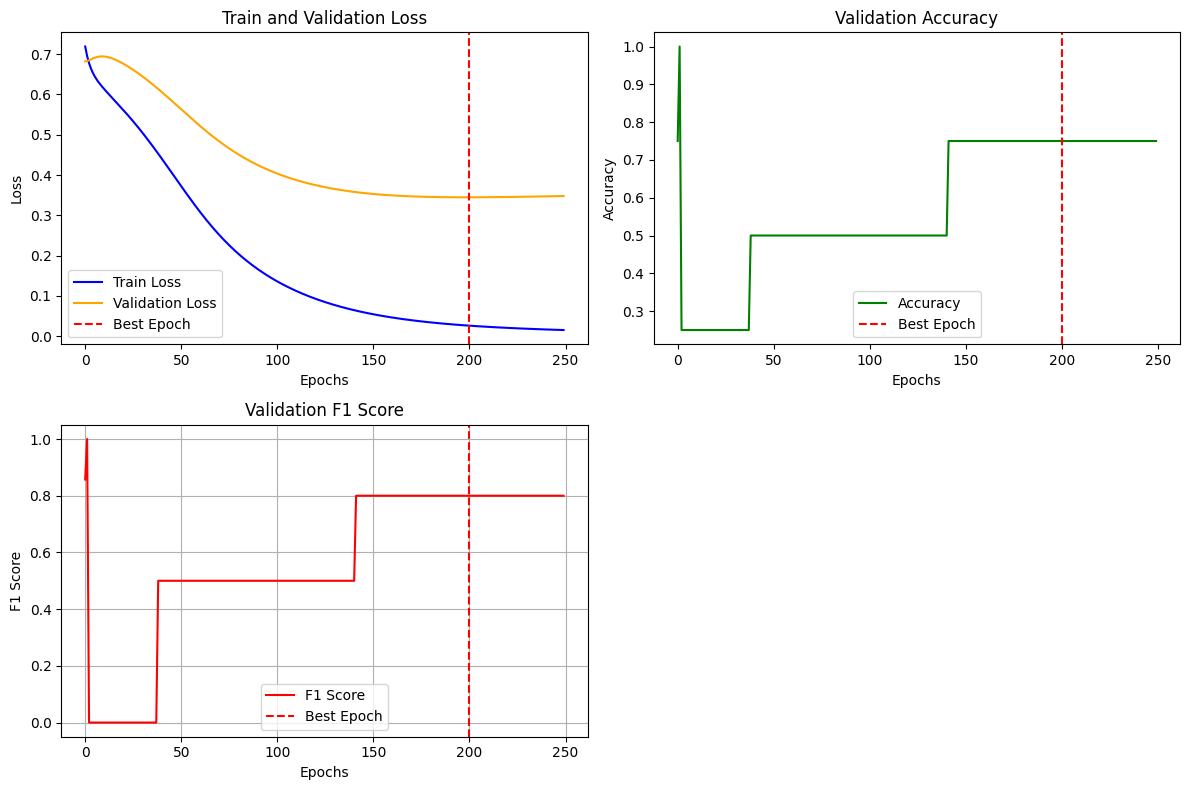

In [4]:
model.load_state_dict(best_model_weights)
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='orange')
plt.axvline(x=best_epoch, color='red', linestyle='--', label='Best Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train and Validation Loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(accuracies, label='Accuracy', color='green')
plt.axvline(x=best_epoch, color='red', linestyle='--', label='Best Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(f1_scores, label='F1 Score', color='red')
plt.axvline(x=best_epoch, color='red', linestyle='--', label='Best Epoch')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('Validation F1 Score')
plt.legend()

plt.tight_layout()
plt.grid(True)
plt.show()
# exit()